In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

## SETUP

In [2]:
np.random.seed(0)

n = 400
p = 50
n_test = 200

q = int(p/3)   # number of features considered at each split

n_runs = 40           # Monte Carlo runs
Bs = [1, 2, 5, 10, 20, 50, 100, 200]   # number of trees

# Notation:
# D = randomness in training data (resampling)
# Θ = randomness in the algorithm (bootstrap + feature subsampling)
# We estimate expectations over both D and Θ via Monte Carlo

## TRUE FUNCTIONS FOR TWO REGIMES

In [3]:
# Regime A: sparse strong signal (few important features)
def true_function_A(X):
    return np.sin(X[:, 0]) + 0.5 * X[:, 1]

# Regime B: dense weak signal (many weak contributors)
def true_function_B(X):
    return np.sum(np.sin(X[:, :10]), axis=1) / 10

## EXPERIMENT FUNCTION

In [4]:
def experiment(true_function):

    # Fixed test set (used to approximate expectation over x)
    X_test = np.random.randn(n_test, p)
    y_test_true = true_function(X_test)

    bias2_list, var_list, mse_list = [], [], []

    for B in Bs:

        preds = []

        for r in range(n_runs):

            # Sample new dataset D^(r)
            X = np.random.randn(n, p)
            y = true_function(X) + 0.5 * np.random.randn(n)

            # Θ = algorithmic randomness (bootstrap + feature subsampling)
            rf = RandomForestRegressor(
                n_estimators=B,
                max_features=q,
                bootstrap=True
            )

            # Each fit() generates a new realization of Θ
            rf.fit(X, y)

            # preds[r, :] = f̂(x; D^(r), Θ^(r)) evaluated on test points
            preds.append(rf.predict(X_test))

        preds = np.array(preds)  # shape: (n_runs, n_test)

        # Mean prediction across runs:
        # ≈ E_{D,Θ}[ f̂(x) ]
        mean_pred = np.mean(preds, axis=0)

        # Bias^2:
        # E_x[ (E[f̂(x)] - f(x))^2 ]
        bias2 = np.mean((mean_pred - y_test_true)**2)

        # Variance:
        # E_x[ Var(f̂(x)) ]
        var = np.mean(np.var(preds, axis=0))

        # Mean Squared Error:
        # E_{x,D,Θ}[ (f̂(x) - f(x))^2 ]
        mse = np.mean((preds - y_test_true)**2)

        bias2_list.append(bias2)
        var_list.append(var)
        mse_list.append(mse)

    return bias2_list, var_list, mse_list

## RUN EXPERIMENTS

In [5]:
bias_A, var_A, mse_A = experiment(true_function_A)
bias_B, var_B, mse_B = experiment(true_function_B)

## PLOTS

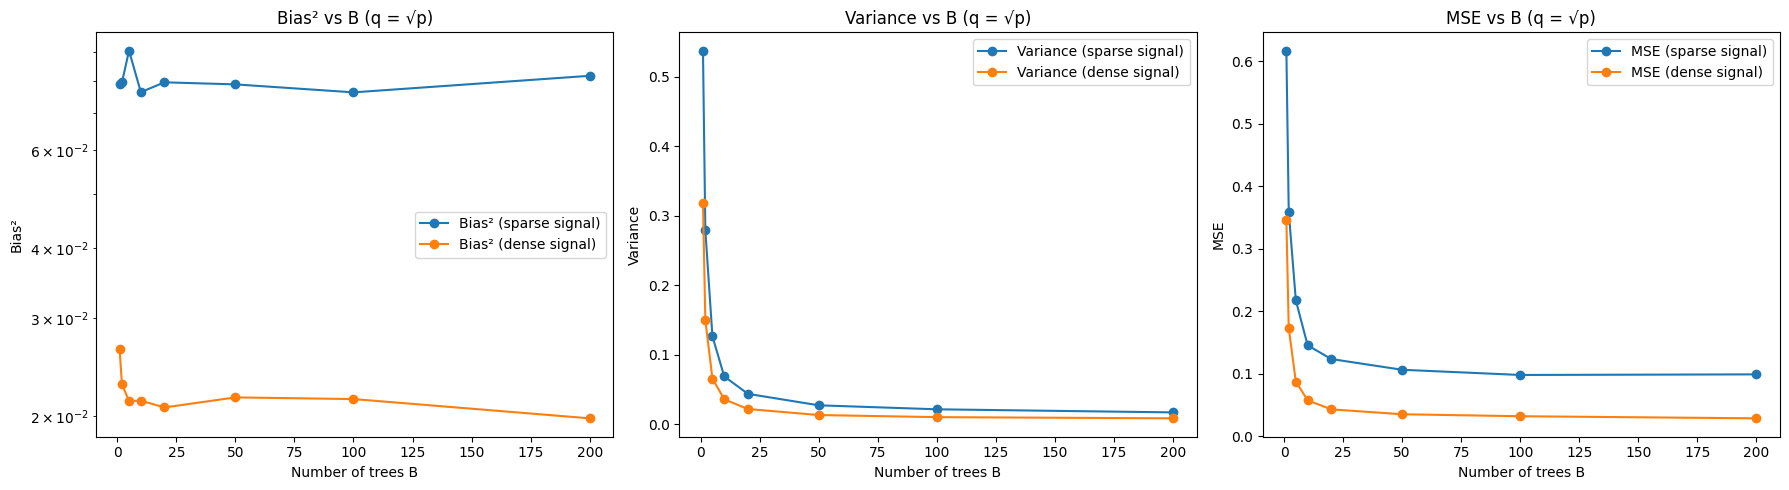

In [6]:
plt.figure(figsize=(18, 5))

# --- Bias² ---
plt.subplot(1, 3, 1)
plt.semilogy(Bs, bias_A, marker='o', label='Bias² (sparse signal)')
plt.semilogy(Bs, bias_B, marker='o', label='Bias² (dense signal)')
plt.xlabel("Number of trees B")
plt.ylabel("Bias²")
plt.title("Bias² vs B (q = √p)")
plt.legend()

# --- Variance ---
plt.subplot(1, 3, 2)
plt.plot(Bs, var_A, marker='o', label='Variance (sparse signal)')
plt.plot(Bs, var_B, marker='o', label='Variance (dense signal)')
plt.xlabel("Number of trees B")
plt.ylabel("Variance")
plt.title("Variance vs B (q = √p)")
plt.legend()

# --- MSE ---
plt.subplot(1, 3, 3)
plt.plot(Bs, mse_A, marker='o', label='MSE (sparse signal)')
plt.plot(Bs, mse_B, marker='o', label='MSE (dense signal)')
plt.xlabel("Number of trees B")
plt.ylabel("MSE")
plt.title("MSE vs B (q = √p)")
plt.legend()

plt.tight_layout()
plt.show()